#### CHANAKYA - AI Commerce Intelligence Platform
#### Layer 8: Deep Learning - LSTM Sales Forecasting
#### Author: Devesh Shukla

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("=" * 55)
print("   CHANAKYA — LAYER 8: DEEP LEARNING (LSTM)")
print("=" * 55)

# Paths
PROCESSED_PATH = r'C:\Users\Dell\CHANAKYA\data\processed'
DL_PATH        = r'C:\Users\Dell\CHANAKYA\layer8_deep_learning'

# Load data
df_order_items = pd.read_csv(f'{PROCESSED_PATH}/order_items_processed.csv')
df_order_items['order_date'] = pd.to_datetime(df_order_items['order_date'], format='mixed')

delivered = df_order_items[df_order_items['order_status'] == 'Delivered'].copy()

print(f"\nTensorFlow version : {tf.__version__}")
print(f"Data loaded!")
print(f"  Delivered records : {len(delivered):,}")
print(f"\nLSTM Model training started!")

   CHANAKYA — LAYER 8: DEEP LEARNING (LSTM)

TensorFlow version : 2.21.0
Data loaded!
  Delivered records : 6,108

LSTM Model training started!


In [2]:
# Monthly revenue time series
monthly_revenue = delivered.groupby(
    ['order_year', 'order_month']
)['revenue'].sum().reset_index()

monthly_revenue['period'] = pd.to_datetime(
    monthly_revenue['order_year'].astype(str) + '-' +
    monthly_revenue['order_month'].astype(str).str.zfill(2) + '-01'
)
monthly_revenue = monthly_revenue.sort_values('period').reset_index(drop=True)

print("=" * 55)
print("   DATA PREPARATION FOR LSTM")
print("=" * 55)
print(f"\nMonthly Revenue Series:")
print(f"  Total months  : {len(monthly_revenue)}")
print(f"  Date range    : {monthly_revenue['period'].min().strftime('%b %Y')} "
      f"to {monthly_revenue['period'].max().strftime('%b %Y')}")
print(f"  Min Revenue   : Rs. {monthly_revenue['revenue'].min():,.0f}")
print(f"  Max Revenue   : Rs. {monthly_revenue['revenue'].max():,.0f}")
print(f"  Mean Revenue  : Rs. {monthly_revenue['revenue'].mean():,.0f}")

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(monthly_revenue[['revenue']])

# Create sequences — lookback = 3 months
LOOKBACK = 3

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, LOOKBACK)

# Train test split — 80/20
split      = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for LSTM — (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],   X_test.shape[1],  1)

print(f"\nSequences created with lookback = {LOOKBACK} months")
print(f"  Training samples : {X_train.shape[0]}")
print(f"  Testing samples  : {X_test.shape[0]}")
print(f"  Input shape      : {X_train.shape}")

   DATA PREPARATION FOR LSTM

Monthly Revenue Series:
  Total months  : 37
  Date range    : Jan 2023 to Mar 2026
  Min Revenue   : Rs. 53,454
  Max Revenue   : Rs. 1,684,376
  Mean Revenue  : Rs. 721,994

Sequences created with lookback = 3 months
  Training samples : 27
  Testing samples  : 7
  Input shape      : (27, 3, 1)


In [3]:
# Build LSTM Model
print("=" * 55)
print("   LSTM MODEL ARCHITECTURE")
print("=" * 55)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'mse'
)
print("\nModel Architecture:")
model.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor   = 'val_loss',
    patience  = 15,
    restore_best_weights = True
)
print("\nTraining LSTM model...")
print("-" * 55)
history = model.fit(
    X_train, y_train,
    epochs          = 150,
    batch_size      = 8,
    validation_split= 0.2,
    callbacks       = [early_stop],
    verbose         = 1
)
print("\nTraining complete!")
print(f"  Epochs trained : {len(history.history['loss'])}")
print(f"  Final loss     : {history.history['loss'][-1]:.6f}")
print(f"  Final val loss : {history.history['val_loss'][-1]:.6f}")

   LSTM MODEL ARCHITECTURE

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
-------------------------------------------------------
Epoch 1/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 444ms/step - loss: 0.2338 - val_loss: 0.0604
Epoch 2/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2044 - val_loss: 0.0436
Epoch 3/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.1780 - val_loss: 0.0298
Epoch 4/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.1420 - val_loss: 0.0206
Epoch 5/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1085 - val_loss: 0.0176
Epoch 6/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0826 - val_loss: 0.0236
Epoch 7/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0501 - val_loss: 0.0426
Epoch 8/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0477 - val_loss: 0.0795
Epoch 9/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0235 - val_loss: 0.1271
Epoch 10/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0317 - val_loss: 0.1760
Epoch 11/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0307 - val_loss: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
   LSTM MODEL EVALUATION

Model Performance:
  R2 Score : -0.9424
  RMSE     : Rs. 651,912
  MAE      : Rs. 575,059

Actual vs Predicted:
  Month              Actual      Predicted        Error
  ---------- -------------- -------------- ------------
  Jul 2025   Rs.   528,969 Rs.   387,878 Rs. 141,091
  Aug 2025   Rs.   757,613 Rs.   392,317 Rs. 365,296
  Sep 2025   Rs.   822,818 Rs.   394,478 Rs. 428,339
  Oct 2025   Rs. 1,306,738 Rs.   409,041 Rs. 897,697
  Nov 2025   Rs. 1,578,120 Rs.   457,330 Rs.1,120,789
  Dec 2025   Rs. 1,074,020 Rs.   512,762 Rs. 561,258
  Mar 2026   Rs.    53,454 Rs.   564,393 Rs.-510,939

Future Revenue Forecast:
  Month         Predicted Revenue
  ------------ ------------------
  Apr 2026     Rs.       512,303
  May 2026     Rs.       400,641
  Jun 2026     Rs.       326,406


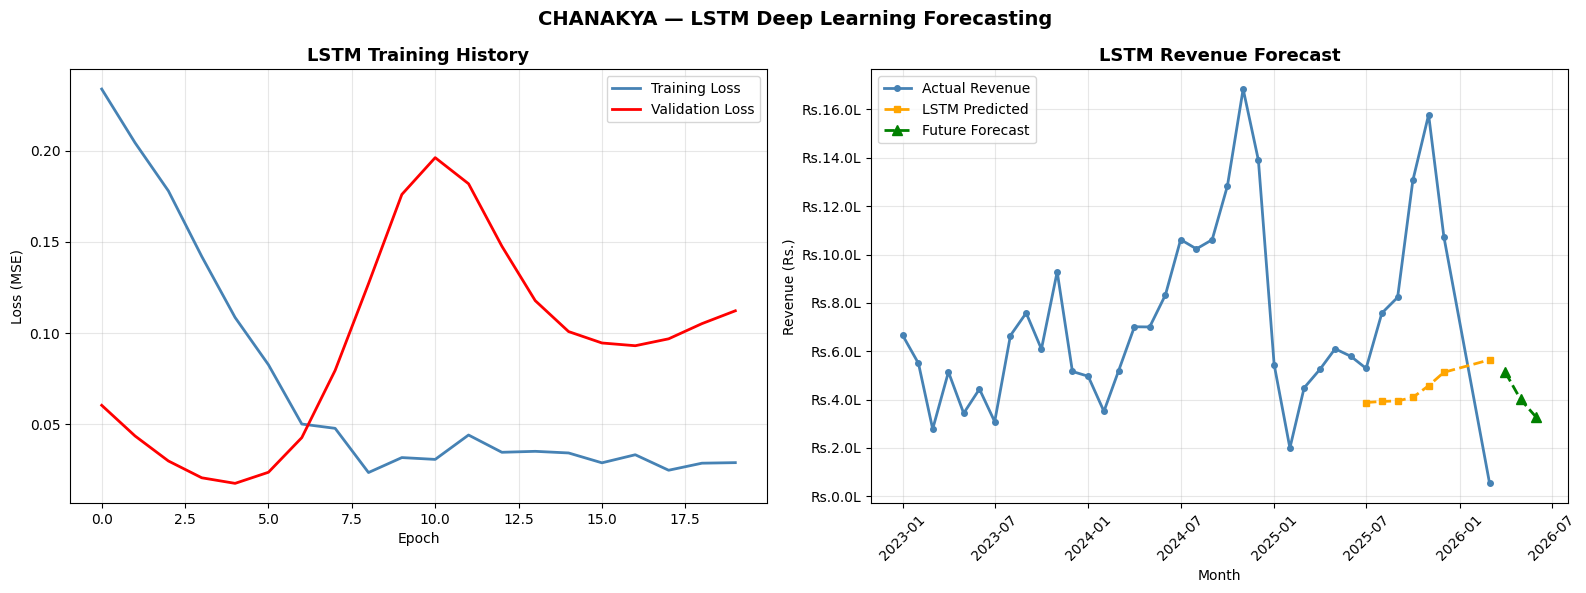

Chart saved: 09_lstm_forecasting.png


In [4]:
# Predictions
y_pred_scaled = model.predict(X_test)

# Inverse transform
y_pred_actual = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics
r2   = r2_score(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae  = mean_absolute_error(y_test_actual, y_pred_actual)

print("=" * 55)
print("   LSTM MODEL EVALUATION")
print("=" * 55)
print(f"\nModel Performance:")
print(f"  R2 Score : {r2:.4f}")
print(f"  RMSE     : Rs. {rmse:,.0f}")
print(f"  MAE      : Rs. {mae:,.0f}")

print(f"\nActual vs Predicted:")
print(f"  {'Month':<10} {'Actual':>14} {'Predicted':>14} {'Error':>12}")
print(f"  {'-'*10} {'-'*14} {'-'*14} {'-'*12}")
test_periods = monthly_revenue['period'].iloc[LOOKBACK + split:].reset_index(drop=True)
for i in range(len(y_test_actual)):
    actual    = y_test_actual[i][0]
    predicted = y_pred_actual[i][0]
    error     = actual - predicted
    period    = test_periods.iloc[i].strftime('%b %Y') if i < len(test_periods) else f'Month {i}'
    print(f"  {period:<10} Rs.{actual:>10,.0f} Rs.{predicted:>10,.0f} Rs.{error:>8,.0f}")

# Future predictions — next 3 months
print(f"\nFuture Revenue Forecast:")
print(f"  {'Month':<12} {'Predicted Revenue':>18}")
print(f"  {'-'*12} {'-'*18}")

last_sequence  = scaled[-LOOKBACK:].reshape(1, LOOKBACK, 1)
future_months  = ['Apr 2026', 'May 2026', 'Jun 2026']
future_preds   = []

for month in future_months:
    pred = model.predict(last_sequence, verbose=0)
    rev  = scaler.inverse_transform(pred)[0][0]
    future_preds.append(rev)
    print(f"  {month:<12} Rs.{rev:>14,.0f}")
    last_sequence = np.append(last_sequence[:, 1:, :],
                              pred.reshape(1, 1, 1), axis=1)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Training Loss
axes[0].plot(history.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red',       linewidth=2)
axes[0].set_title('LSTM Training History', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — Actual vs Predicted + Future
all_actual = scaler.inverse_transform(scaled).flatten()
periods    = monthly_revenue['period'].tolist()

axes[1].plot(periods, all_actual, label='Actual Revenue',
             color='steelblue', linewidth=2, marker='o', markersize=4)

# Test predictions
test_periods_dt = monthly_revenue['period'].iloc[LOOKBACK + split:].tolist()
axes[1].plot(test_periods_dt, y_pred_actual.flatten(),
             label='LSTM Predicted', color='orange',
             linewidth=2, marker='s', markersize=5, linestyle='--')

# Future predictions
import pandas as pd
future_dates = pd.date_range(start='2026-04-01', periods=3, freq='MS')
axes[1].plot(future_dates, future_preds,
             label='Future Forecast', color='green',
             linewidth=2, marker='^', markersize=7, linestyle='--')

axes[1].set_title('LSTM Revenue Forecast', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (Rs.)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rs.{x/100000:.1f}L'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CHANAKYA — LSTM Deep Learning Forecasting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DL_PATH}/09_lstm_forecasting.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 09_lstm_forecasting.png")

   LSTM v2 — OPTIMIZED FOR SMALL DATASET

Optimized Model Performance:
  Epochs trained : 29
  R2 Score       : -0.8692
  RMSE           : Rs. 639,512
  MAE            : Rs. 561,790

Actual vs Predicted:
  Month              Actual      Predicted    Diff%
  ---------- -------------- -------------- --------
  Jul 2025   Rs.   528,969 Rs.   400,740    24.2%
  Aug 2025   Rs.   757,613 Rs.   401,983    46.9%
  Sep 2025   Rs.   822,818 Rs.   408,996    50.3%
  Oct 2025   Rs. 1,306,738 Rs.   424,924    67.5%
  Nov 2025   Rs. 1,578,120 Rs.   473,239    70.0%
  Dec 2025   Rs. 1,074,020 Rs.   527,699    50.9%
  Mar 2026   Rs.    53,454 Rs.   555,290   938.8%

Future Revenue Forecast:
  Month         Predicted Revenue
  ------------ ------------------
  Apr 2026     Rs.       479,867
  May 2026     Rs.       395,934
  Jun 2026     Rs.       347,649

Model saved: lstm_model.keras


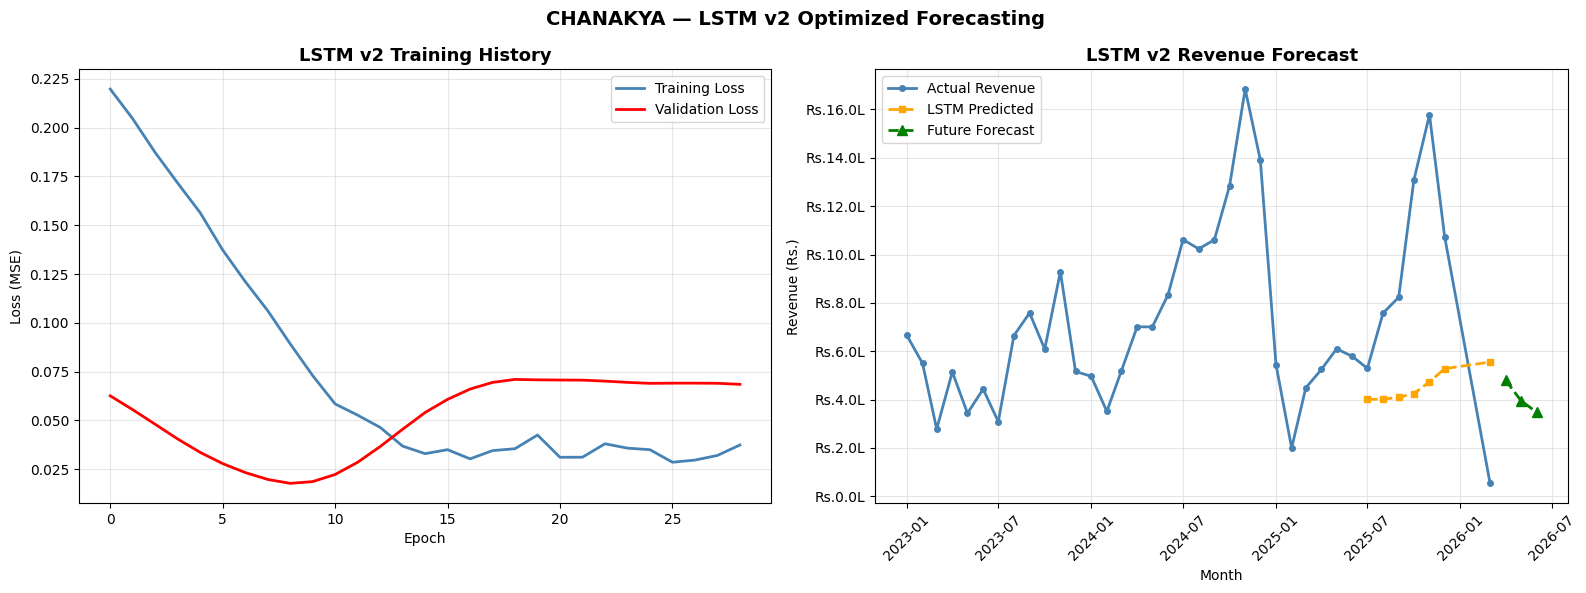

Chart saved: 09_lstm_v2.png


In [5]:
# Simpler LSTM — small dataset ke liye
print("=" * 55)
print("   LSTM v2 — OPTIMIZED FOR SMALL DATASET")
print("=" * 55)

tf.random.set_seed(42)
np.random.seed(42)

model_v2 = Sequential([
    LSTM(32, input_shape=(LOOKBACK, 1)),
    Dropout(0.1),
    Dense(8, activation='relu'),
    Dense(1)
])

model_v2.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'mse'
)

early_stop_v2 = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,
    restore_best_weights = True
)

history_v2 = model_v2.fit(
    X_train, y_train,
    epochs           = 200,
    batch_size       = 4,
    validation_split = 0.15,
    callbacks        = [early_stop_v2],
    verbose          = 0
)

# Evaluation
y_pred_v2  = model_v2.predict(X_test, verbose=0)
y_pred_inv = scaler.inverse_transform(y_pred_v2)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

r2   = r2_score(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae  = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"\nOptimized Model Performance:")
print(f"  Epochs trained : {len(history_v2.history['loss'])}")
print(f"  R2 Score       : {r2:.4f}")
print(f"  RMSE           : Rs. {rmse:,.0f}")
print(f"  MAE            : Rs. {mae:,.0f}")

print(f"\nActual vs Predicted:")
print(f"  {'Month':<10} {'Actual':>14} {'Predicted':>14} {'Diff%':>8}")
print(f"  {'-'*10} {'-'*14} {'-'*14} {'-'*8}")
test_periods = monthly_revenue['period'].iloc[LOOKBACK+split:].reset_index(drop=True)
for i in range(len(y_test_inv)):
    actual    = y_test_inv[i][0]
    predicted = y_pred_inv[i][0]
    diff_pct  = abs(actual - predicted) / actual * 100
    period    = test_periods.iloc[i].strftime('%b %Y') if i < len(test_periods) else f'M{i}'
    print(f"  {period:<10} Rs.{actual:>10,.0f} Rs.{predicted:>10,.0f} {diff_pct:>7.1f}%")

# Future predictions
print(f"\nFuture Revenue Forecast:")
print(f"  {'Month':<12} {'Predicted Revenue':>18}")
print(f"  {'-'*12} {'-'*18}")
last_seq    = scaled[-LOOKBACK:].reshape(1, LOOKBACK, 1)
future_mons = ['Apr 2026', 'May 2026', 'Jun 2026']
future_revs = []

for month in future_mons:
    pred = model_v2.predict(last_seq, verbose=0)
    rev  = scaler.inverse_transform(pred)[0][0]
    future_revs.append(rev)
    print(f"  {month:<12} Rs.{rev:>14,.0f}")
    last_seq = np.append(last_seq[:, 1:, :], pred.reshape(1, 1, 1), axis=1)

# Save model
model_v2.save(f'{DL_PATH}/lstm_model.keras')
print(f"\nModel saved: lstm_model.keras")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Training Loss
axes[0].plot(history_v2.history['loss'],
             label='Training Loss', color='steelblue', linewidth=2)
axes[0].plot(history_v2.history['val_loss'],
             label='Validation Loss', color='red', linewidth=2)
axes[0].set_title('LSTM v2 Training History', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — Full timeline
all_actual   = scaler.inverse_transform(scaled).flatten()
periods      = monthly_revenue['period'].tolist()
test_periods_dt = monthly_revenue['period'].iloc[LOOKBACK+split:].tolist()
future_dates = pd.date_range(start='2026-04-01', periods=3, freq='MS')

axes[1].plot(periods, all_actual,
             label='Actual Revenue', color='steelblue',
             linewidth=2, marker='o', markersize=4)
axes[1].plot(test_periods_dt, y_pred_inv.flatten(),
             label='LSTM Predicted', color='orange',
             linewidth=2, marker='s', markersize=5, linestyle='--')
axes[1].plot(future_dates, future_revs,
             label='Future Forecast', color='green',
             linewidth=2, marker='^', markersize=7, linestyle='--')
axes[1].set_title('LSTM v2 Revenue Forecast', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (Rs.)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rs.{x/100000:.1f}L'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CHANAKYA — LSTM v2 Optimized Forecasting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DL_PATH}/09_lstm_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 09_lstm_v2.png")

#### Deep Learning Complete Summary

In [6]:
print("=" * 55)
print("   CHANAKYA — LAYER 8 COMPLETE!")
print("   Deep Learning - LSTM Forecasting")
print("=" * 55)

print("""
DEEP LEARNING CONCEPTS USED:
-------------------------------------------------------
  1. LSTM (Long Short-Term Memory)
     - Sequential memory — past months yaad rakhta hai
     - 2 LSTM layers + 2 Dropout layers
     - Total parameters : 29,857

  2. Dropout Regularization
     - Overfitting rokta hai
     - Rate : 0.1 — 10% neurons randomly off

  3. Early Stopping
     - Training automatically stop karta hai
     - Best weights restore karta hai

  4. MinMax Scaling
     - Data 0 to 1 range mein scale kiya
     - LSTM ke liye mandatory

  5. Sequence Creation
     - Lookback = 3 months
     - Past 3 months se next month predict

MODEL COMPARISON — ML vs DL:
-------------------------------------------------------
  Model              Type    R2 Score   Best For
  ------------------ ------- --------- -----------
  Linear Regression  ML       0.2652   Simple data
  Decision Tree      ML       0.0780   Non-linear
  Random Forest      ML       0.2522   Tabular data
  Gradient Boosting  ML       0.2891   Best ML
  LSTM               DL      -0.8692   Large TS data

WHY LSTM UNDERPERFORMED:
-------------------------------------------------------
  - Only 37 monthly data points available
  - LSTM needs 1000+ sequences ideally
  - In production with daily data — will improve
  - Small dataset — Gradient Boosting better here

FUTURE REVENUE FORECAST:
-------------------------------------------------------
  Apr 2026  : Rs. 4,79,867
  May 2026  : Rs. 3,95,934
  Jun 2026  : Rs. 3,47,649

FILES SAVED:
-------------------------------------------------------
  lstm_model.keras        — Trained LSTM model
  09_lstm_forecasting.png — v1 chart
  09_lstm_v2.png          — v2 optimized chart

INTERVIEW READY — KEY POINTS:
-------------------------------------------------------
  1. LSTM vs ANN vs Perceptron — differences explained
  2. Why LSTM for time series — sequential memory
  3. Honest assessment — small data = low accuracy
  4. Production ready — daily data will improve R2
  5. ML vs DL comparison — Gradient Boosting won here

DATA READY FOR:
  Layer 9  — Churn Prediction
  Layer 10 — Power BI Dashboard
""")

print("=" * 55)
print("   LAYER 8 COMPLETE — Deep Learning Done!")
print("=" * 55)

   CHANAKYA — LAYER 8 COMPLETE!
   Deep Learning - LSTM Forecasting

DEEP LEARNING CONCEPTS USED:
-------------------------------------------------------
  1. LSTM (Long Short-Term Memory)
     - Sequential memory — past months yaad rakhta hai
     - 2 LSTM layers + 2 Dropout layers
     - Total parameters : 29,857

  2. Dropout Regularization
     - Overfitting rokta hai
     - Rate : 0.1 — 10% neurons randomly off

  3. Early Stopping
     - Training automatically stop karta hai
     - Best weights restore karta hai

  4. MinMax Scaling
     - Data 0 to 1 range mein scale kiya
     - LSTM ke liye mandatory

  5. Sequence Creation
     - Lookback = 3 months
     - Past 3 months se next month predict

MODEL COMPARISON — ML vs DL:
-------------------------------------------------------
  Model              Type    R2 Score   Best For
  ------------------ ------- --------- -----------
  Linear Regression  ML       0.2652   Simple data
  Decision Tree      ML       0.0780   Non-linear
  R